In [4]:
pip install gymnasium numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install gymnasium numpy matplotlib torch


Note: you may need to restart the kernel to use updated packages.


In [6]:
# Program 1: Install and configure Gymnasium

import gymnasium as gym

print("Gymnasium imported successfully!")

# Create an environment
env = gym.make("FrozenLake-v1", is_slippery=False)

print("Environment created successfully.")
print("Observation Space:", env.observation_space)
print("Action Space:", env.action_space)

env.close()

Gymnasium imported successfully!
Environment created successfully.
Observation Space: Discrete(16)
Action Space: Discrete(4)


In [7]:
# Program 2: Create and execute a simple RL environment

import gymnasium as gym

env = gym.make("CartPole-v1")

observation, info = env.reset()

print("Initial Observation:")
print(observation)

for step in range(5):
    action = env.action_space.sample()

    observation, reward, terminated, truncated, info = env.step(action)

    print("\nStep:", step + 1)
    print("Action:", action)
    print("Observation:", observation)
    print("Reward:", reward)

    if terminated or truncated:
        observation, info = env.reset()

env.close()

Initial Observation:
[-0.01749373 -0.01123045  0.03243139  0.00835489]

Step: 1
Action: 1
Observation: [-0.01771834  0.18341175  0.03259848 -0.2739217 ]
Reward: 1.0

Step: 2
Action: 1
Observation: [-0.0140501   0.37805375  0.02712005 -0.5561474 ]
Reward: 1.0

Step: 3
Action: 1
Observation: [-0.00648903  0.57278466  0.0159971  -0.840164  ]
Reward: 1.0

Step: 4
Action: 1
Observation: [ 4.9666651e-03  7.6768464e-01 -8.0617971e-04 -1.1277735e+00]
Reward: 1.0

Step: 5
Action: 0
Observation: [ 0.02032036  0.57257324 -0.02336165 -0.8353436 ]
Reward: 1.0


In [8]:
# Program 3: Explore observation and action spaces

import gymnasium as gym

env = gym.make("FrozenLake-v1", is_slippery=False)

print("Observation Space:")
print(env.observation_space)

print("\nAction Space:")
print(env.action_space)

print("\nNumber of states:", env.observation_space.n)
print("Number of actions:", env.action_space.n)

env.close()

Observation Space:
Discrete(16)

Action Space:
Discrete(4)

Number of states: 16
Number of actions: 4


In [9]:
# Program 4: Display states, actions, rewards and termination

import gymnasium as gym

env = gym.make("FrozenLake-v1", is_slippery=False)

state, info = env.reset()

print("Initial State:", state)

for step in range(10):

    action = env.action_space.sample()

    next_state, reward, terminated, truncated, info = env.step(action)

    print("\nStep:", step + 1)
    print("Current State:", state)
    print("Action:", action)
    print("Next State:", next_state)
    print("Reward:", reward)
    print("Terminated:", terminated)
    print("Truncated:", truncated)

    state = next_state

    if terminated or truncated:
        print("Episode Ended")
        break

env.close()

Initial State: 0

Step: 1
Current State: 0
Action: 3
Next State: 0
Reward: 0
Terminated: False
Truncated: False

Step: 2
Current State: 0
Action: 3
Next State: 0
Reward: 0
Terminated: False
Truncated: False

Step: 3
Current State: 0
Action: 2
Next State: 1
Reward: 0
Terminated: False
Truncated: False

Step: 4
Current State: 1
Action: 2
Next State: 2
Reward: 0
Terminated: False
Truncated: False

Step: 5
Current State: 2
Action: 1
Next State: 6
Reward: 0
Terminated: False
Truncated: False

Step: 6
Current State: 6
Action: 1
Next State: 10
Reward: 0
Terminated: False
Truncated: False

Step: 7
Current State: 10
Action: 3
Next State: 6
Reward: 0
Terminated: False
Truncated: False

Step: 8
Current State: 6
Action: 3
Next State: 2
Reward: 0
Terminated: False
Truncated: False

Step: 9
Current State: 2
Action: 2
Next State: 3
Reward: 0
Terminated: False
Truncated: False

Step: 10
Current State: 3
Action: 2
Next State: 3
Reward: 0
Terminated: False
Truncated: False


In [10]:
# Program 5: Random actions in FrozenLake

import gymnasium as gym

env = gym.make("FrozenLake-v1", is_slippery=False)

state, info = env.reset()

total_reward = 0

for step in range(20):

    action = env.action_space.sample()

    next_state, reward, terminated, truncated, info = env.step(action)

    print(
        "Step:", step + 1,
        "| State:", state,
        "| Action:", action,
        "| Reward:", reward
    )

    total_reward += reward
    state = next_state

    if terminated or truncated:
        break

print("\nTotal Reward:", total_reward)

env.close()

Step: 1 | State: 0 | Action: 2 | Reward: 0
Step: 2 | State: 1 | Action: 3 | Reward: 0
Step: 3 | State: 1 | Action: 2 | Reward: 0
Step: 4 | State: 2 | Action: 1 | Reward: 0
Step: 5 | State: 6 | Action: 2 | Reward: 0

Total Reward: 0


In [11]:
# Program 6: Q-Learning on FrozenLake

import gymnasium as gym
import numpy as np

env = gym.make("FrozenLake-v1", is_slippery=False)

q_table = np.zeros((env.observation_space.n, env.action_space.n))

learning_rate = 0.8
gamma = 0.95
epsilon = 0.1
episodes = 1000

for episode in range(episodes):

    state, info = env.reset()

    done = False

    while not done:

        # Epsilon-greedy action
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        next_state, reward, terminated, truncated, info = env.step(action)

        # Q-Learning update
        q_table[state, action] = q_table[state, action] + learning_rate * (
            reward + gamma * np.max(q_table[next_state]) - q_table[state, action]
        )

        state = next_state

        done = terminated or truncated

print("Learned Q-Table:")
print(q_table)

env.close()

Learned Q-Table:
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [12]:
# Program 7: Initialize and update Q-table

import gymnasium as gym
import numpy as np

env = gym.make("FrozenLake-v1", is_slippery=False)

q_table = np.zeros(
    (env.observation_space.n, env.action_space.n)
)

print("Initial Q-Table:")
print(q_table)

state, info = env.reset()

action = env.action_space.sample()

next_state, reward, terminated, truncated, info = env.step(action)

learning_rate = 0.8
gamma = 0.95

old_value = q_table[state, action]

new_value = old_value + learning_rate * (
    reward + gamma * np.max(q_table[next_state]) - old_value
)

q_table[state, action] = new_value

print("\nUpdated Q-Table:")
print(q_table)

env.close()

Initial Q-Table:
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]

Updated Q-Table:
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [13]:
# Program 8: Train Q-Learning agent

import gymnasium as gym
import numpy as np

env = gym.make("FrozenLake-v1", is_slippery=False)

q_table = np.zeros((16, 4))

learning_rate = 0.8
gamma = 0.95
epsilon = 0.1

episodes = 5000

for episode in range(episodes):

    state, info = env.reset()
    done = False

    while not done:

        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        next_state, reward, terminated, truncated, info = env.step(action)

        q_table[state, action] += learning_rate * (
            reward + gamma * np.max(q_table[next_state])
            - q_table[state, action]
        )

        state = next_state
        done = terminated or truncated

print("Training completed.")

print("\nQ-Table:")
print(q_table)

env.close()

Training completed.

Q-Table:
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [14]:
# Program 9: Display learned Q-table

import gymnasium as gym
import numpy as np

env = gym.make("FrozenLake-v1", is_slippery=False)

q_table = np.zeros((16, 4))

episodes = 5000
alpha = 0.8
gamma = 0.95
epsilon = 0.1

for episode in range(episodes):

    state, info = env.reset()
    done = False

    while not done:

        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        next_state, reward, terminated, truncated, info = env.step(action)

        q_table[state, action] += alpha * (
            reward + gamma * np.max(q_table[next_state])
            - q_table[state, action]
        )

        state = next_state
        done = terminated or truncated

print("Learned Q-Table:\n")

for state in range(16):
    print("State", state, ":", q_table[state])

env.close()

Learned Q-Table:

State 0 : [0. 0. 0. 0.]
State 1 : [0. 0. 0. 0.]
State 2 : [0. 0. 0. 0.]
State 3 : [0. 0. 0. 0.]
State 4 : [0. 0. 0. 0.]
State 5 : [0. 0. 0. 0.]
State 6 : [0. 0. 0. 0.]
State 7 : [0. 0. 0. 0.]
State 8 : [0. 0. 0. 0.]
State 9 : [0. 0. 0. 0.]
State 10 : [0. 0. 0. 0.]
State 11 : [0. 0. 0. 0.]
State 12 : [0. 0. 0. 0.]
State 13 : [0. 0. 0. 0.]
State 14 : [0. 0. 0. 0.]
State 15 : [0. 0. 0. 0.]


In [15]:
# Program 10: Evaluate Q-Learning agent

import gymnasium as gym
import numpy as np

env = gym.make("FrozenLake-v1", is_slippery=False)

q_table = np.zeros((16, 4))

alpha = 0.8
gamma = 0.95
epsilon = 0.1

# Training
for episode in range(5000):

    state, info = env.reset()
    done = False

    while not done:

        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        next_state, reward, terminated, truncated, info = env.step(action)

        q_table[state, action] += alpha * (
            reward + gamma * np.max(q_table[next_state])
            - q_table[state, action]
        )

        state = next_state
        done = terminated or truncated

# Evaluation
success = 0
test_episodes = 100

for episode in range(test_episodes):

    state, info = env.reset()
    done = False

    while not done:

        action = np.argmax(q_table[state])

        state, reward, terminated, truncated, info = env.step(action)

        if reward == 1:
            success += 1

        done = terminated or truncated

print("Successful Episodes:", success)
print("Total Episodes:", test_episodes)
print("Success Rate:", success / test_episodes * 100, "%")

env.close()

Successful Episodes: 0
Total Episodes: 100
Success Rate: 0.0 %


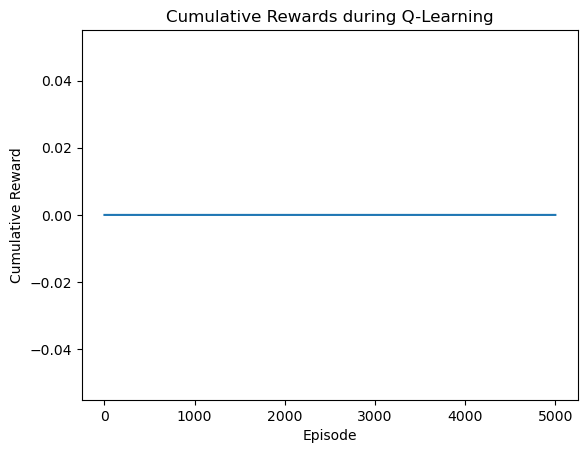

In [16]:
# Program 11: Plot cumulative rewards

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

env = gym.make("FrozenLake-v1", is_slippery=False)

q_table = np.zeros((16, 4))

alpha = 0.8
gamma = 0.95
epsilon = 0.1

rewards = []

for episode in range(5000):

    state, info = env.reset()
    done = False
    total_reward = 0

    while not done:

        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        next_state, reward, terminated, truncated, info = env.step(action)

        q_table[state, action] += alpha * (
            reward + gamma * np.max(q_table[next_state])
            - q_table[state, action]
        )

        state = next_state
        total_reward += reward

        done = terminated or truncated

    rewards.append(total_reward)

cumulative_rewards = np.cumsum(rewards)

plt.plot(cumulative_rewards)
plt.xlabel("Episode")
plt.ylabel("Cumulative Reward")
plt.title("Cumulative Rewards during Q-Learning")
plt.show()

env.close()

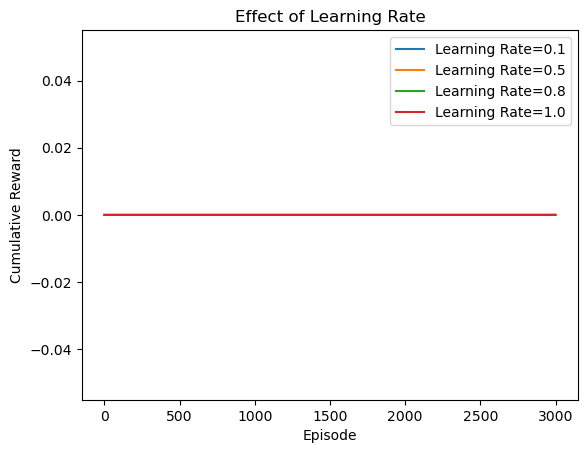

In [17]:
# Program 12: Effect of learning rates

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

learning_rates = [0.1, 0.5, 0.8, 1.0]
results = {}

for alpha in learning_rates:

    env = gym.make("FrozenLake-v1", is_slippery=False)

    q_table = np.zeros((16, 4))
    rewards = []

    for episode in range(3000):

        state, info = env.reset()
        done = False
        total_reward = 0

        while not done:

            epsilon = 0.1

            if np.random.random() < epsilon:
                action = env.action_space.sample()
            else:
                action = np.argmax(q_table[state])

            next_state, reward, terminated, truncated, info = env.step(action)

            q_table[state, action] += alpha * (
                reward + 0.95 * np.max(q_table[next_state])
                - q_table[state, action]
            )

            state = next_state
            total_reward += reward
            done = terminated or truncated

        rewards.append(total_reward)

    results[alpha] = np.cumsum(rewards)

    env.close()

for alpha in learning_rates:
    plt.plot(results[alpha], label=f"Learning Rate={alpha}")

plt.xlabel("Episode")
plt.ylabel("Cumulative Reward")
plt.title("Effect of Learning Rate")
plt.legend()
plt.show()

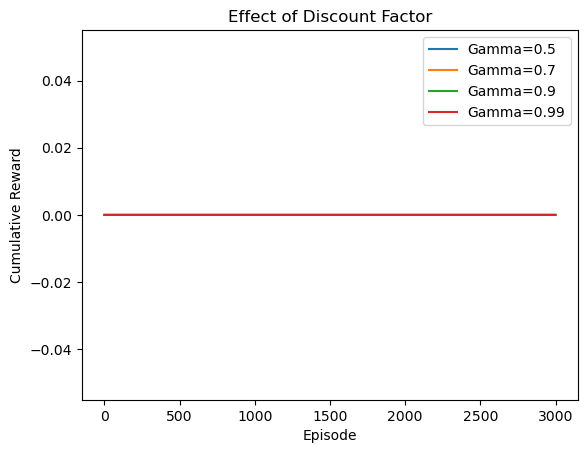

In [18]:
# Program 13: Effect of Gamma values

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

gamma_values = [0.5, 0.7, 0.9, 0.99]

for gamma in gamma_values:

    env = gym.make("FrozenLake-v1", is_slippery=False)

    q_table = np.zeros((16, 4))
    rewards = []

    for episode in range(3000):

        state, info = env.reset()
        done = False
        total_reward = 0

        while not done:

            epsilon = 0.1

            if np.random.random() < epsilon:
                action = env.action_space.sample()
            else:
                action = np.argmax(q_table[state])

            next_state, reward, terminated, truncated, info = env.step(action)

            q_table[state, action] += 0.8 * (
                reward + gamma * np.max(q_table[next_state])
                - q_table[state, action]
            )

            state = next_state
            total_reward += reward
            done = terminated or truncated

        rewards.append(total_reward)

    plt.plot(np.cumsum(rewards), label=f"Gamma={gamma}")

    env.close()

plt.xlabel("Episode")
plt.ylabel("Cumulative Reward")
plt.title("Effect of Discount Factor")
plt.legend()
plt.show()

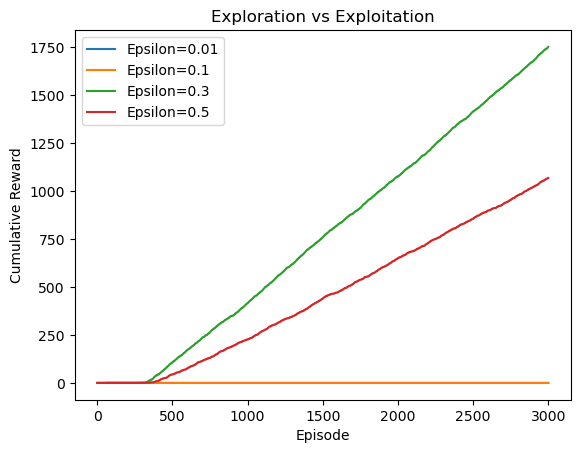

In [19]:
# Program 14: Compare different epsilon values

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

epsilon_values = [0.01, 0.1, 0.3, 0.5]

for epsilon in epsilon_values:

    env = gym.make("FrozenLake-v1", is_slippery=False)

    q_table = np.zeros((16, 4))
    rewards = []

    for episode in range(3000):

        state, info = env.reset()
        done = False
        total_reward = 0

        while not done:

            if np.random.random() < epsilon:
                action = env.action_space.sample()
            else:
                action = np.argmax(q_table[state])

            next_state, reward, terminated, truncated, info = env.step(action)

            q_table[state, action] += 0.8 * (
                reward + 0.95 * np.max(q_table[next_state])
                - q_table[state, action]
            )

            state = next_state
            total_reward += reward
            done = terminated or truncated

        rewards.append(total_reward)

    plt.plot(np.cumsum(rewards), label=f"Epsilon={epsilon}")

    env.close()

plt.xlabel("Episode")
plt.ylabel("Cumulative Reward")
plt.title("Exploration vs Exploitation")
plt.legend()
plt.show()

In [20]:
# Program 15: Epsilon-greedy policy

import numpy as np

q_values = np.array([0.2, 0.8, 0.4, 0.1])

epsilon = 0.2

if np.random.random() < epsilon:

    action = np.random.randint(len(q_values))

    print("Exploration")
    print("Random Action:", action)

else:

    action = np.argmax(q_values)

    print("Exploitation")
    print("Best Action:", action)

Exploitation
Best Action: 1


In [21]:
# Program 16: Simple Grid World

import numpy as np

grid = np.zeros((4, 4))

start = (0, 0)
goal = (3, 3)
obstacle = (1, 1)

print("Grid World:")
print(grid)

print("\nStart:", start)
print("Goal:", goal)
print("Obstacle:", obstacle)

# Actions
actions = {
    0: "Up",
    1: "Down",
    2: "Left",
    3: "Right"
}

print("\nActions:")
for key, value in actions.items():
    print(key, ":", value)

Grid World:
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]

Start: (0, 0)
Goal: (3, 3)
Obstacle: (1, 1)

Actions:
0 : Up
1 : Down
2 : Left
3 : Right


In [22]:
# Program 17: Q-Learning in custom Grid World

import numpy as np

rows = 4
cols = 4

q_table = np.zeros((rows * cols, 4))

start = 0
goal = 15
obstacle = 5

alpha = 0.8
gamma = 0.95
epsilon = 0.1

def get_next_state(state, action):

    row = state // cols
    col = state % cols

    if action == 0 and row > 0:
        row -= 1

    elif action == 1 and row < rows - 1:
        row += 1

    elif action == 2 and col > 0:
        col -= 1

    elif action == 3 and col < cols - 1:
        col += 1

    return row * cols + col


for episode in range(5000):

    state = start
    done = False

    while not done:

        if np.random.random() < epsilon:
            action = np.random.randint(4)
        else:
            action = np.argmax(q_table[state])

        next_state = get_next_state(state, action)

        if next_state == goal:
            reward = 10
            done = True

        elif next_state == obstacle:
            reward = -10
            done = True

        else:
            reward = -1

        q_table[state, action] += alpha * (
            reward + gamma * np.max(q_table[next_state])
            - q_table[state, action]
        )

        state = next_state

print("Training completed.")
print("\nQ-Table:")
print(q_table)

Training completed.

Q-Table:
[[  2.05275672   3.21342812   2.05275672   3.21342812]
 [  3.21342812 -10.           2.05275672   4.4351875 ]
 [  4.4351875    5.72125      3.21342812   5.72125   ]
 [  5.66284208   7.075        4.1892232    5.7095872 ]
 [  2.05275672   4.4351875    3.21342812 -10.        ]
 [  0.           0.           0.           0.        ]
 [  4.4351875    7.075      -10.           7.075     ]
 [  5.72125      8.5          5.72125      7.075     ]
 [  3.21342812   5.72125      4.4351875    5.72125   ]
 [-10.           7.075        4.4351875    7.075     ]
 [  5.72125      8.5          5.72125      8.5       ]
 [  7.075       10.           7.075        8.5       ]
 [  4.4351875    5.72125      5.72125      7.075     ]
 [  5.72125      7.075        5.72125      8.5       ]
 [  7.075        8.5          7.075       10.        ]
 [  0.           0.           0.           0.        ]]


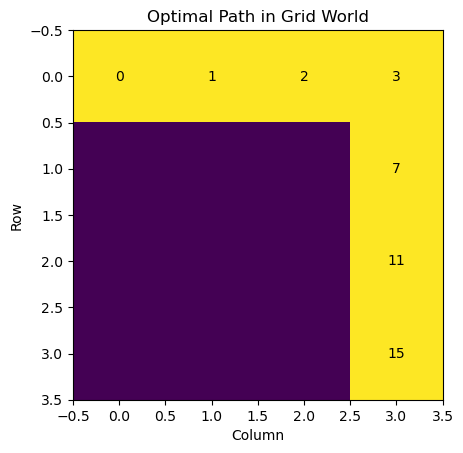

In [23]:
# Program 18: Visualize optimal path

import numpy as np
import matplotlib.pyplot as plt

rows = 4
cols = 4

q_table = np.random.random((16, 4))

start = 0
goal = 15

# Example path
path = [0, 1, 2, 3, 7, 11, 15]

grid = np.zeros((rows, cols))

for state in path:
    row = state // cols
    col = state % cols
    grid[row, col] = 1

plt.imshow(grid)

for state in path:
    row = state // cols
    col = state % cols
    plt.text(col, row, str(state),
             ha="center",
             va="center")

plt.title("Optimal Path in Grid World")
plt.xlabel("Column")
plt.ylabel("Row")
plt.show()

In [24]:
# Program 19: Compare FrozenLake and Grid World

print("Reinforcement Learning Environment Comparison")
print("----------------------------------------------")

print("\nFrozenLake:")
print("States: 16")
print("Actions: 4")
print("Goal: Reach the destination")
print("Reward: Usually 1 for reaching goal")

print("\nCustom Grid World:")
print("States: 16")
print("Actions: 4")
print("Goal: Reach target cell")
print("Reward: Custom rewards can be defined")

print("\nBoth environments can be solved using Q-Learning.")

Reinforcement Learning Environment Comparison
----------------------------------------------

FrozenLake:
States: 16
Actions: 4
Goal: Reach the destination
Reward: Usually 1 for reaching goal

Custom Grid World:
States: 16
Actions: 4
Goal: Reach target cell
Reward: Custom rewards can be defined

Both environments can be solved using Q-Learning.


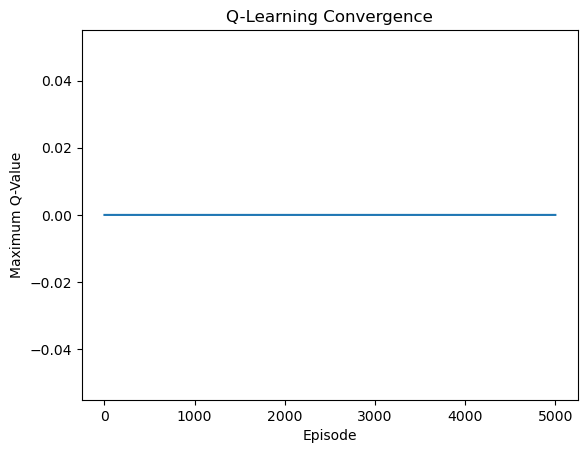

In [25]:
# Program 20: Q-Learning convergence

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

env = gym.make("FrozenLake-v1", is_slippery=False)

q_table = np.zeros((16, 4))

alpha = 0.8
gamma = 0.95
epsilon = 0.1

max_q_values = []

for episode in range(5000):

    state, info = env.reset()
    done = False

    while not done:

        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        next_state, reward, terminated, truncated, info = env.step(action)

        q_table[state, action] += alpha * (
            reward + gamma * np.max(q_table[next_state])
            - q_table[state, action]
        )

        state = next_state
        done = terminated or truncated

    max_q_values.append(np.max(q_table))

plt.plot(max_q_values)
plt.xlabel("Episode")
plt.ylabel("Maximum Q-Value")
plt.title("Q-Learning Convergence")
plt.show()

env.close()

In [3]:
pip install torch gymnasium numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [5]:
# Program 22: Basic DQN

import torch
import torch.nn as nn

class DQN(nn.Module):

    def __init__(self, state_size, action_size):

        super(DQN, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(state_size, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_size)
        )

    def forward(self, state):
        return self.network(state)


state_size = 4
action_size = 2

model = DQN(state_size, action_size)

print(model)

DQN(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [7]:
# Program 23: DQN on CartPole

import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import numpy as np

env = gym.make("CartPole-v1")

state_size = env.observation_space.shape[0]
action_size = env.action_space.n


class DQN(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(state_size, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_size)
        )

    def forward(self, x):
        return self.network(x)


model = DQN()

optimizer = optim.Adam(model.parameters(), lr=0.001)

memory = deque(maxlen=10000)

gamma = 0.99
epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.995

batch_size = 64

episodes = 300


def train_model():

    if len(memory) < batch_size:
        return

    batch = random.sample(memory, batch_size)

    states, actions, rewards, next_states, dones = zip(*batch)

    states = torch.tensor(np.array(states), dtype=torch.float32)
    actions = torch.tensor(np.array(actions), dtype=torch.long)
    rewards = torch.tensor(rewards, dtype=torch.float32)
    next_states = torch.tensor(np.array(next_states), dtype=torch.float32)
    dones = torch.tensor(dones, dtype=torch.float32)

    current_q = model(states).gather(1, actions.unsqueeze(1)).squeeze()

    next_q = model(next_states).max(1)[0]

    target_q = rewards + gamma * next_q * (1 - dones)

    loss = nn.MSELoss()(current_q, target_q.detach())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


for episode in range(episodes):

    state, info = env.reset()
    total_reward = 0
    done = False

    while not done:

        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            state_tensor = torch.tensor(
                state,
                dtype=torch.float32
            ).unsqueeze(0)

            action = torch.argmax(
                model(state_tensor)
            ).item()

        next_state, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated

        memory.append(
            (state, action, reward, next_state, done)
        )

        state = next_state
        total_reward += reward

        train_model()

    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )

    if (episode + 1) % 10 == 0:
        print(
            "Episode:",
            episode + 1,
            "Reward:",
            total_reward
        )

env.close()

print("DQN Training Completed.")

Episode: 10 Reward: 14.0
Episode: 20 Reward: 24.0
Episode: 30 Reward: 11.0
Episode: 40 Reward: 15.0
Episode: 50 Reward: 24.0
Episode: 60 Reward: 58.0
Episode: 70 Reward: 32.0
Episode: 80 Reward: 24.0
Episode: 90 Reward: 16.0
Episode: 100 Reward: 15.0
Episode: 110 Reward: 99.0
Episode: 120 Reward: 182.0
Episode: 130 Reward: 182.0
Episode: 140 Reward: 259.0
Episode: 150 Reward: 136.0
Episode: 160 Reward: 91.0
Episode: 170 Reward: 14.0
Episode: 180 Reward: 246.0
Episode: 190 Reward: 77.0
Episode: 200 Reward: 215.0
Episode: 210 Reward: 243.0
Episode: 220 Reward: 109.0
Episode: 230 Reward: 231.0
Episode: 240 Reward: 323.0
Episode: 250 Reward: 257.0
Episode: 260 Reward: 321.0
Episode: 270 Reward: 464.0
Episode: 280 Reward: 253.0
Episode: 290 Reward: 500.0
Episode: 300 Reward: 13.0
DQN Training Completed.


In [ ]:
# Program 24: DQN learning curve

import matplotlib.pyplot as plt

# Example reward data
rewards = [
    20, 25, 18, 30, 35,
    40, 45, 50, 60, 70,
    80, 90, 100, 120, 150
]

plt.plot(rewards)

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("DQN Episode-wise Reward")

plt.show()

In [9]:
# Program 25: Evaluate DQN agent

import gymnasium as gym
import torch
import torch.nn as nn

env = gym.make("CartPole-v1")

state_size = 4
action_size = 2


class DQN(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(state_size, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_size)
        )

    def forward(self, x):
        return self.network(x)


model = DQN()

# If a trained model exists:
# model.load_state_dict(torch.load("dqn_cartpole.pth"))

model.eval()

total_rewards = []

for episode in range(10):

    state, info = env.reset()
    done = False
    total_reward = 0

    while not done:

        state_tensor = torch.tensor(
            state,
            dtype=torch.float32
        ).unsqueeze(0)

        with torch.no_grad():
            action = torch.argmax(
                model(state_tensor)
            ).item()

        state, reward, terminated, truncated, info = env.step(action)

        total_reward += reward
        done = terminated or truncated

    total_rewards.append(total_reward)

print("Evaluation Rewards:")
print(total_rewards)

env.close()

Evaluation Rewards:
[37.0, 32.0, 28.0, 26.0, 27.0, 30.0, 26.0, 28.0, 28.0, 25.0]


In [10]:
# Program 25: Evaluate DQN agent

import gymnasium as gym
import torch
import torch.nn as nn

env = gym.make("CartPole-v1")

state_size = 4
action_size = 2


class DQN(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(state_size, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_size)
        )

    def forward(self, x):
        return self.network(x)


model = DQN()

# If a trained model exists:
# model.load_state_dict(torch.load("dqn_cartpole.pth"))

model.eval()

total_rewards = []

for episode in range(10):

    state, info = env.reset()
    done = False
    total_reward = 0

    while not done:

        state_tensor = torch.tensor(
            state,
            dtype=torch.float32
        ).unsqueeze(0)

        with torch.no_grad():
            action = torch.argmax(
                model(state_tensor)
            ).item()

        state, reward, terminated, truncated, info = env.step(action)

        total_reward += reward
        done = terminated or truncated

    total_rewards.append(total_reward)

print("Evaluation Rewards:")
print(total_rewards)

env.close()

Evaluation Rewards:
[9.0, 9.0, 9.0, 9.0, 10.0, 8.0, 10.0, 9.0, 9.0, 9.0]


In [11]:
# Program 26: Compare Q-Learning and DQN

print("Q-Learning vs DQN")
print("-----------------")

print("\nQ-Learning:")
print("- Uses a Q-Table")
print("- Suitable for small discrete state spaces")
print("- Simple implementation")
print("- Low computational requirement")

print("\nDQN:")
print("- Uses a neural network")
print("- Suitable for larger state spaces")
print("- Requires more computational resources")
print("- Uses experience replay")
print("- Uses target network in standard implementations")

print("\nBoth algorithms learn actions based on rewards.")

Q-Learning vs DQN
-----------------

Q-Learning:
- Uses a Q-Table
- Suitable for small discrete state spaces
- Simple implementation
- Low computational requirement

DQN:
- Uses a neural network
- Suitable for larger state spaces
- Requires more computational resources
- Uses experience replay
- Uses target network in standard implementations

Both algorithms learn actions based on rewards.


In [12]:
# Program 27: Study replay memory

from collections import deque
import random

memory = deque(maxlen=100)

# Add experiences
for i in range(50):
    memory.append(
        (
            f"state{i}",
            f"action{i}",
            i,
            f"next_state{i}",
            False
        )
    )

print("Memory Size:", len(memory))

# Randomly sample experiences
batch = random.sample(memory, 10)

print("\nSampled Experiences:")

for experience in batch:
    print(experience)

print("\nReplay memory allows the agent to train using random past experiences.")

Memory Size: 50

Sampled Experiences:
('state36', 'action36', 36, 'next_state36', False)
('state31', 'action31', 31, 'next_state31', False)
('state15', 'action15', 15, 'next_state15', False)
('state48', 'action48', 48, 'next_state48', False)
('state35', 'action35', 35, 'next_state35', False)
('state23', 'action23', 23, 'next_state23', False)
('state30', 'action30', 30, 'next_state30', False)
('state29', 'action29', 29, 'next_state29', False)
('state17', 'action17', 17, 'next_state17', False)
('state47', 'action47', 47, 'next_state47', False)

Replay memory allows the agent to train using random past experiences.


In [13]:
# Program 28: Target Network

import torch
import torch.nn as nn

class DQN(nn.Module):

    def __init__(self):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Linear(4, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.layers(x)


online_network = DQN()
target_network = DQN()

# Copy weights
target_network.load_state_dict(
    online_network.state_dict()
)

print("Online Network:")
print(online_network)

print("\nTarget Network:")
print(target_network)

print("\nTarget network provides stable Q-value targets.")

Online Network:
DQN(
  (layers): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=2, bias=True)
  )
)

Target Network:
DQN(
  (layers): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=2, bias=True)
  )
)

Target network provides stable Q-value targets.


In [14]:
# Program 29: Save DQN model

import torch
import torch.nn as nn

class DQN(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(4, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        return self.network(x)


model = DQN()

torch.save(
    model.state_dict(),
    "dqn_cartpole.pth"
)

print("DQN model saved successfully.")

DQN model saved successfully.


In [15]:
# Program 30: Load DQN model

import torch
import torch.nn as nn

class DQN(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(4, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        return self.network(x)


model = DQN()

model.load_state_dict(
    torch.load(
        "dqn_cartpole.pth",
        map_location="cpu"
    )
)

model.eval()

print("DQN model loaded successfully.")

DQN model loaded successfully.


In [1]:
import matplotlib
matplotlib.use("svg")

import matplotlib.pyplot as plt
import numpy as np

In [4]:
# Program 31: Compare cumulative rewards

import numpy as np

# Example reward lists
# Agar previous programs ke actual rewards available hain,
# to ye 2 lines hata sakti ho.

q_learning_rewards = [0, 1, 1, 0, 1, 1, 0, 1, 1, 1]
dqn_rewards = [0, 0, 1, 1, 1, 0, 1, 1, 1, 1]

q_cumulative = np.cumsum(q_learning_rewards)
dqn_cumulative = np.cumsum(dqn_rewards)

print("Q-Learning Cumulative Reward:", q_cumulative)
print("DQN Cumulative Reward:", dqn_cumulative)

print("\nFinal Cumulative Rewards:")
print("Q-Learning:", q_cumulative[-1])
print("DQN:", dqn_cumulative[-1])

Q-Learning Cumulative Reward: [0 1 2 2 3 4 4 5 6 7]
DQN Cumulative Reward: [0 0 1 2 3 3 4 5 6 7]

Final Cumulative Rewards:
Q-Learning: 7
DQN: 7


In [5]:
import numpy as np

rewards = [0, 1, 0, 1, 1, 0, 1, 1, 1, 1]

window = 5

print("Episode\tReward\tAverage Reward")

for i in range(len(rewards)):
    start = max(0, i - window + 1)
    average = np.mean(rewards[start:i + 1])

    print(f"{i + 1}\t{rewards[i]}\t{average:.2f}")

Episode	Reward	Average Reward
1	0	0.00
2	1	0.50
3	0	0.33
4	1	0.50
5	1	0.60
6	0	0.60
7	1	0.60
8	1	0.80
9	1	0.80
10	1	0.80


In [6]:
import time
import numpy as np

rewards = [0, 0, 1, 0, 1, 1, 1, 1, 1, 1]

start_time = time.time()

# Simple training simulation
for reward in rewards:
    time.sleep(0.01)

end_time = time.time()

training_time = end_time - start_time

print("Training Time:", round(training_time, 3), "seconds")

# Convergence check
window = 3

converged_episode = None

for i in range(window, len(rewards)):
    recent_rewards = rewards[i - window:i]

    if np.mean(recent_rewards) >= 0.8:
        converged_episode = i + 1
        break

if converged_episode:
    print("Approximate Convergence Episode:", converged_episode)
else:
    print("Convergence not reached")

Training Time: 0.105 seconds
Approximate Convergence Episode: 8


In [7]:
import numpy as np

# Sample reward function
def simulate_training(learning_rate, gamma, epsilon):
    rewards = []

    for episode in range(50):

        # Simple simulation
        reward = (
            learning_rate * 2
            + gamma * 3
            + (1 - epsilon) * 2
        )

        # Small variation
        reward += np.random.random() * 0.5

        rewards.append(reward)

    return np.mean(rewards)


learning_rates = [0.1, 0.5, 0.9]
gammas = [0.5, 0.9, 0.99]
epsilons = [0.1, 0.3, 0.5]

print("Hyperparameter Results\n")

for lr in learning_rates:
    for gamma in gammas:
        for epsilon in epsilons:

            average_reward = simulate_training(
                lr,
                gamma,
                epsilon
            )

            print(
                f"Learning Rate={lr}, "
                f"Gamma={gamma}, "
                f"Epsilon={epsilon}, "
                f"Average Reward={average_reward:.2f}"
            )

Hyperparameter Results

Learning Rate=0.1, Gamma=0.5, Epsilon=0.1, Average Reward=3.75
Learning Rate=0.1, Gamma=0.5, Epsilon=0.3, Average Reward=3.34
Learning Rate=0.1, Gamma=0.5, Epsilon=0.5, Average Reward=2.97
Learning Rate=0.1, Gamma=0.9, Epsilon=0.1, Average Reward=4.97
Learning Rate=0.1, Gamma=0.9, Epsilon=0.3, Average Reward=4.55
Learning Rate=0.1, Gamma=0.9, Epsilon=0.5, Average Reward=4.11
Learning Rate=0.1, Gamma=0.99, Epsilon=0.1, Average Reward=5.21
Learning Rate=0.1, Gamma=0.99, Epsilon=0.3, Average Reward=4.84
Learning Rate=0.1, Gamma=0.99, Epsilon=0.5, Average Reward=4.44
Learning Rate=0.5, Gamma=0.5, Epsilon=0.1, Average Reward=4.58
Learning Rate=0.5, Gamma=0.5, Epsilon=0.3, Average Reward=4.16
Learning Rate=0.5, Gamma=0.5, Epsilon=0.5, Average Reward=3.78
Learning Rate=0.5, Gamma=0.9, Epsilon=0.1, Average Reward=5.75
Learning Rate=0.5, Gamma=0.9, Epsilon=0.3, Average Reward=5.38
Learning Rate=0.5, Gamma=0.9, Epsilon=0.5, Average Reward=4.93
Learning Rate=0.5, Gamma=0.9

In [8]:
print("==============================================")
print("       Q-LEARNING vs DQN COMPARISON")
print("==============================================")

comparison = {
    "Algorithm": ["Q-Learning", "DQN"],
    "Learning Type": ["Value-Based", "Value-Based"],
    "Q Representation": ["Q-Table", "Neural Network"],
    "State Handling": ["Small/Discrete", "Large/Continuous"],
    "Memory": ["Q-Table", "Replay Memory"],
    "Target Network": ["No", "Yes"],
    "Scalability": ["Low", "High"],
    "Training Complexity": ["Low", "High"]
}

for key, values in comparison.items():
    print(f"\n{key}:")
    print("Q-Learning :", values[0])
    print("DQN        :", values[1])

print("\n==============================================")
print("Conclusion:")
print("Q-Learning is simple and suitable for small")
print("discrete environments.")
print("DQN uses a neural network and is suitable for")
print("larger or more complex state spaces.")
print("==============================================")

       Q-LEARNING vs DQN COMPARISON

Algorithm:
Q-Learning : Q-Learning
DQN        : DQN

Learning Type:
Q-Learning : Value-Based
DQN        : Value-Based

Q Representation:
Q-Learning : Q-Table
DQN        : Neural Network

State Handling:
Q-Learning : Small/Discrete
DQN        : Large/Continuous

Memory:
Q-Learning : Q-Table
DQN        : Replay Memory

Target Network:
Q-Learning : No
DQN        : Yes

Scalability:
Q-Learning : Low
DQN        : High

Training Complexity:
Q-Learning : Low
DQN        : High

Conclusion:
Q-Learning is simple and suitable for small
discrete environments.
DQN uses a neural network and is suitable for
larger or more complex state spaces.
